### Step 1: Initialize Libraries
Import essential libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), video processing (`cv2`), and progress tracking (`tqdm`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import IPython.display as ipd
from tqdm.notebook import tqdm
import cv2

*Optimization:* Consolidate all imports in the first cell to ensure dependencies are loaded before logic starts.

### Step 2: Video Preview
Display a low-resolution preview of the sample video to verify the file path and content.

In [2]:
video_path = "video_sample.mp4"
ipd.Video(video_path, width=200)

### Step 3: Extract Video Metadata
Open the video stream using OpenCV and retrieve technical specifications including total frames, resolution (height/width), and frames per second (FPS).

In [3]:
cap = cv2.VideoCapture(video_path)
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
fps = cap.get(cv2.CAP_PROP_FPS)

print(f'Total Frames: {total_frames}')
print(f'Resolution: {width}x{height}')
print(f'FPS: {fps:0.2f}')

Total Frames: 2398.0
Resolution: 1280.0x720.0
FPS: 59.94


### Step 4: Extract and Visualize First Frame
Read the first frame of the video into a NumPy array and display it using Matplotlib.

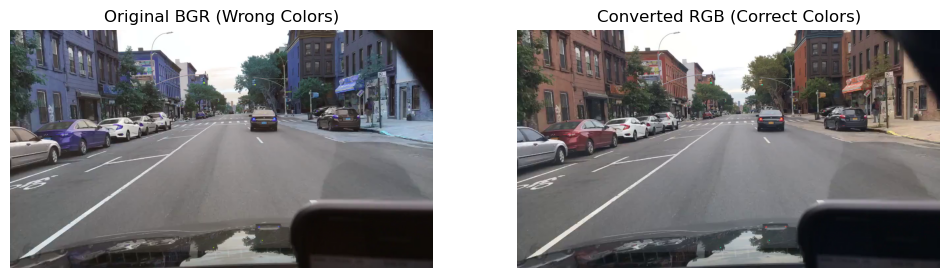

In [4]:
### Comparison: Why we need to change the color format
# Read the frame
ret, img = cap.read()

if ret:
    plt.figure(figsize=(12, 6))
    
    # 1. Display original BGR (How OpenCV reads it)
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original BGR (Wrong Colors)")
    plt.axis('off')
    
    # 2. Display converted RGB (The correct way for Matplotlib)
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Converted RGB (Correct Colors)")
    plt.axis('off')
    
    plt.show()

*Optimization:* OpenCV loads images in BGR format. For accurate colors in Matplotlib, use 'cv2.cvtColor(img, cv2.COLOR_BGR2RGB)'. Also, add 'plt.axis("off")' to remove unnecessary graph coordinates from the image view.

{'Frames': 2398.0, 'FPS': 59.94, 'Dims': (1280, 720)}


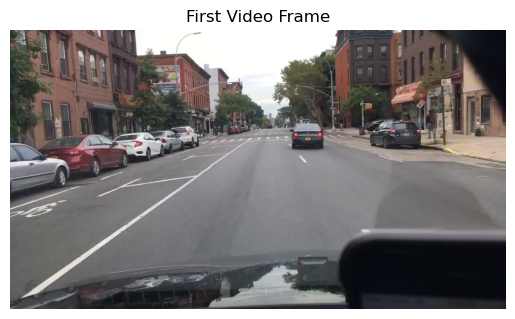

In [5]:
# OPTIMIZED CELL
cap = cv2.VideoCapture(video_path)

# 1. Metadata
info = {
    "Frames": cap.get(cv2.CAP_PROP_FRAME_COUNT),
    "FPS": round(cap.get(cv2.CAP_PROP_FPS), 2),
    "Dims": (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
}
print(info)

# 2. Frame Extraction (Reads from the already open stream)
ret, img = cap.read()
if ret:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("First Video Frame")
    plt.axis('off')

cap.release()

### Step 5: Extract and Display Multiple Frames
This section iterates through specific intervals of the video (e.g., every 500 frames) to capture and display snapshots across the duration of the clip.

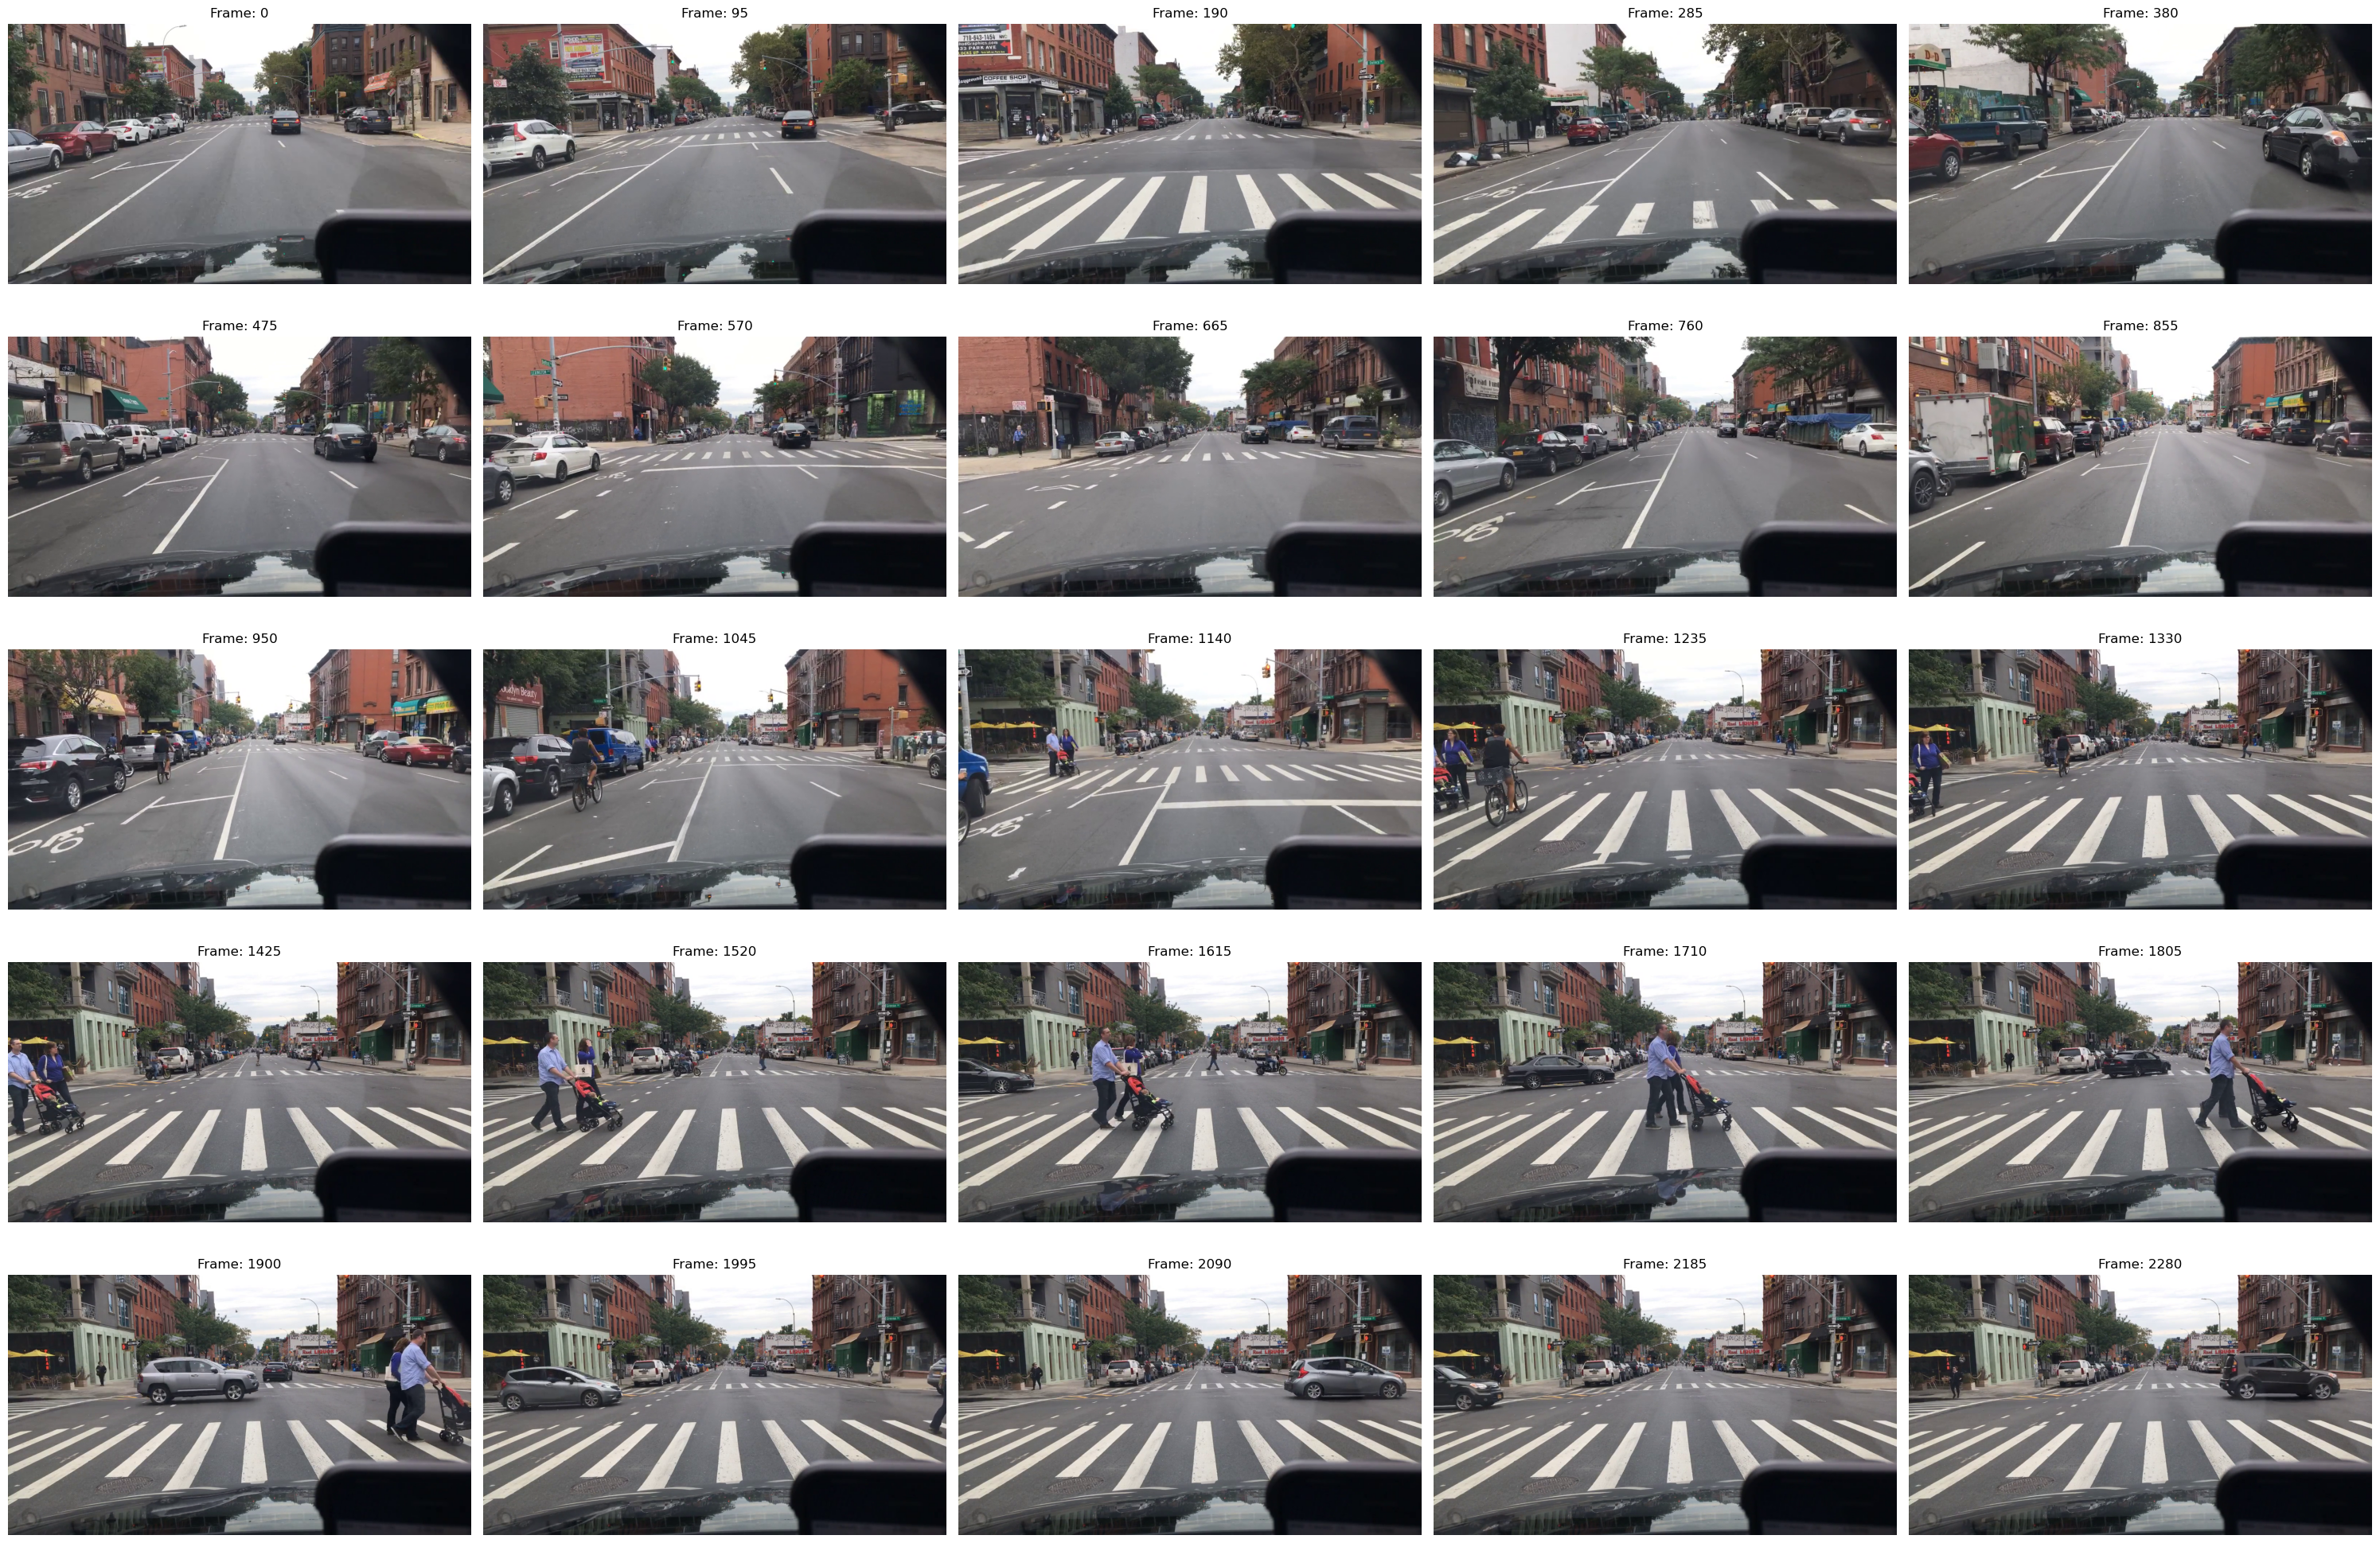

In [8]:
# Initialize video capture
cap = cv2.VideoCapture('video_sample.mp4')

# Calculate intervals to fit a 5x5 grid
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
interval = total_frames // 25  # Divide into 25 equal segments

# Set up the 5x5 grid structure
fig, axs = plt.subplots(5, 5, figsize=(30, 20))
axs = axs.flatten()

for i in range(25):
    frame_idx = i * interval
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    
    if ret:
        # Convert BGR (OpenCV) to RGB (Matplotlib) for correct colors
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axs[i].imshow(frame_rgb)
        axs[i].set_title(f"Frame: {frame_idx}", fontsize=12)
    
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Release the video capture resource
cap.release()